In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Load the raw panel
df = pd.read_csv('../data/country_panel.csv')

print(f'Shape before cleaning: {df.shape}')
print(f'Countries: {df.country_code.nunique()}')
display(df.head())

Shape before cleaning: (7328, 28)
Countries: 229


,country_name,country_code,year,gdp_per_capita,inflation,unemployment,trade_pct_gdp,govt_expenditure,urban_pop_pct,internet_users,...,bank_roe,bank_deposits_gdp,life_expectancy,child_mortality,fertility_rate,clean_water_access,primary_enrollment,secondary_enrollment,edu_expenditure,literacy_rate
0,Aruba,ABW,1990,12187.53636,5.836688,NaN,NaN,NaN,65.432816,0.0,...,NaN,49.63587,72.546,NaN,2.345,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1991,13233.99052,5.555556,NaN,NaN,NaN,65.400922,NaN,...,NaN,51.45119,72.592,NaN,2.362,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,1992,13892.60514,3.873375,NaN,NaN,NaN,65.390589,NaN,...,NaN,53.37284,72.717,NaN,2.353,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,1993,14700.95981,5.215560,NaN,NaN,NaN,65.384467,NaN,...,NaN,49.85363,72.777,NaN,2.331,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,1994,16055.28779,6.311080,NaN,NaN,NaN,65.380048,NaN,...,NaN,49.58435,72.796,NaN,2.298,NaN,NaN,NaN,NaN,NaN


In [3]:
# === STEP 1: DROP COLUMNS ===
# Based on EDA findings:
# - literacy_rate: 84.7% missing — too sparse
# - bank_assets_gdp: 0.96 correlation with private_credit_gdp — redundant
# - bank_deposits_gdp: 0.92 correlation with bank_assets_gdp — redundant
# - child_mortality: -0.92 correlation with life_expectancy — redundant
# - fertility_rate: 0.85 correlation with child_mortality — redundant
# - bank_roa + bank_roe: 0.63 corr with each other, 56% missing — keep only bank_roa
# - net_interest_margin: 56.7% missing, captured by other bank indicators

cols_to_drop = [
    'literacy_rate',        # 84.7% missing
    'bank_assets_gdp',      # redundant with private_credit_gdp (r=0.96)
    'bank_deposits_gdp',    # redundant with bank_assets_gdp (r=0.92)
    'child_mortality',      # redundant with life_expectancy (r=-0.92)
    'fertility_rate',       # redundant with child_mortality (r=0.85)
    'bank_roe',             # redundant with bank_roa (r=0.63), keep bank_roa
    'net_interest_margin',  # 56.7% missing, covered by other bank indicators
]

df = df.drop(columns=cols_to_drop)

print(f'Shape after dropping columns: {df.shape}')
print(f'Remaining columns:\n{df.columns.tolist()}')

Shape after dropping columns: (7328, 21)
Remaining columns:
['country_name', 'country_code', 'year', 'gdp_per_capita', 'inflation', 'unemployment', 'trade_pct_gdp', 'govt_expenditure', 'urban_pop_pct', 'internet_users', 'private_credit_gdp', 'liquid_liabilities_gdp', 'bank_zscore', 'bank_npl', 'bank_capital_ratio', 'bank_roa', 'life_expectancy', 'clean_water_access', 'primary_enrollment', 'secondary_enrollment', 'edu_expenditure']


=== MISSING DATA DISTRIBUTION ACROSS COUNTRIES ===
count    229.0
mean      31.2
std       17.5
min       10.3
25%       16.7
50%       26.6
75%       42.5
max       75.9
dtype: float64


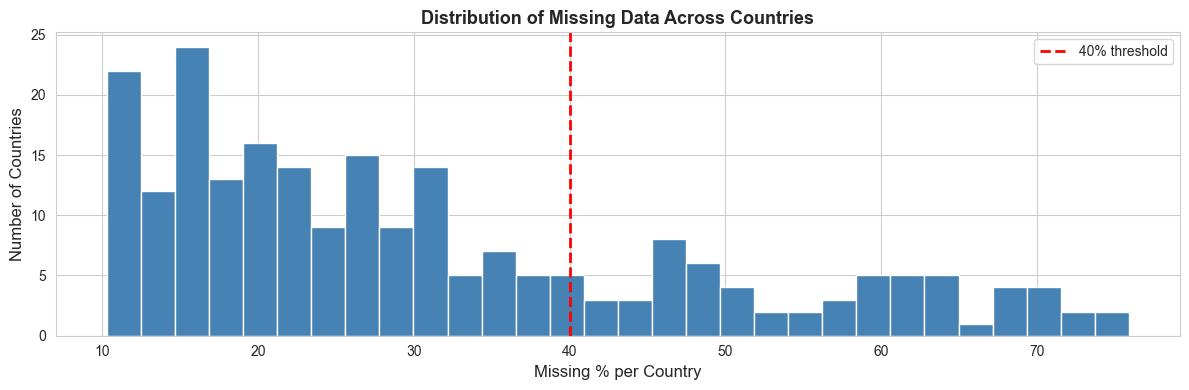


Countries with >40% missing: 61
country_code
MAF    75.9
SXM    75.5
IMN    73.0
CHI    71.6
GIB    71.1
TCA    70.9
MNP    70.2
VGB    70.0
ASM    69.1
PRK    68.1
GRL    68.1
XKX    68.0
FRO    66.2
MCO    64.7
CUW    64.2
CYM    64.1
SOM    63.7
TUV    63.6
NRU    62.7
LIE    62.5
dtype: float64


In [4]:
# === STEP 2: FILTER COUNTRIES ===
# Remove countries that have too much missing data overall
# A country with >50% missing across all indicators is not useful for ML
# (the model can't learn from a country it barely knows anything about)

# Calculate missing % per country
country_missing = df.groupby('country_code').apply(
    lambda x: x.isnull().sum().sum() / (x.shape[0] * x.shape[1]) * 100
).round(1)

# See the distribution of missingness across countries
print('=== MISSING DATA DISTRIBUTION ACROSS COUNTRIES ===')
print(country_missing.describe().round(1))

# Plot
plt.figure(figsize=(12, 4))
plt.hist(country_missing, bins=30, color='steelblue', edgecolor='white')
plt.axvline(x=40, color='red', linestyle='--', linewidth=2, label='40% threshold')
plt.xlabel('Missing % per Country', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.title('Distribution of Missing Data Across Countries', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Countries above threshold
high_missing = country_missing[country_missing > 40]
print(f'\nCountries with >40% missing: {len(high_missing)}')
print(high_missing.sort_values(ascending=False).head(20))

In [5]:
# === REMOVE COUNTRIES WITH >40% MISSING ===

countries_to_keep = country_missing[country_missing <= 40].index
df = df[df['country_code'].isin(countries_to_keep)]

print(f'Countries removed: {229 - df.country_code.nunique()}')
print(f'Countries remaining: {df.country_code.nunique()}')
print(f'Shape after country filter: {df.shape}')

# Confirm our key countries are still there
key_countries = ['USA', 'IND', 'CHN', 'BRA', 'DEU', 'NGA', 'ZAF', 'IDN']
present = [c for c in key_countries if c in df.country_code.values]
print(f'\nKey countries still present: {present}')

Countries removed: 61
Countries remaining: 168
Shape after country filter: (5376, 21)

Key countries still present: ['USA', 'IND', 'CHN', 'BRA', 'DEU', 'NGA', 'ZAF', 'IDN']


In [6]:
# === STEP 3: CAP EXTREME OUTLIERS ===
# From EDA we saw inflation has extreme values (max 23,773%!)
# These are hyperinflation cases (Zimbabwe, Venezuela)
# We don't want to DROP these countries — they're real and important
# Instead we CAP the values at a reasonable maximum

print('=== BEFORE CAPPING ===')
print(df['inflation'].describe().round(2))

# Cap inflation at 100% — anything above is hyperinflation
# The model learns "this is very high inflation" without being distorted
# by values like 23,000% which are statistical outliers
df['inflation'] = df['inflation'].clip(lower=-20, upper=100)

# Also cap bank_npl at 100% (it's a percentage, can't exceed 100)
df['bank_npl'] = df['bank_npl'].clip(lower=0, upper=100)

# Cap primary and secondary enrollment at 110%
# (values above 110 are data quality issues — older students re-enrolling)
df['primary_enrollment']   = df['primary_enrollment'].clip(upper=110)
df['secondary_enrollment'] = df['secondary_enrollment'].clip(upper=110)

print('\n=== AFTER CAPPING ===')
print(df['inflation'].describe().round(2))

print('\nCapping summary:')
print(f'  inflation        → capped at [-20, 100]')
print(f'  bank_npl         → capped at [0, 100]')
print(f'  primary_enrollment  → capped at 110')
print(f'  secondary_enrollment → capped at 110')

=== BEFORE CAPPING ===
count     5002.00
mean        27.14
std        388.17
min        -16.86
25%          1.81
50%          3.98
75%          8.60
max      23773.13
Name: inflation, dtype: float64

=== AFTER CAPPING ===
count    5002.00
mean        9.03
std        17.06
min       -16.86
25%         1.81
50%         3.98
75%         8.60
max       100.00
Name: inflation, dtype: float64

Capping summary:
  inflation        → capped at [-20, 100]
  bank_npl         → capped at [0, 100]
  primary_enrollment  → capped at 110
  secondary_enrollment → capped at 110


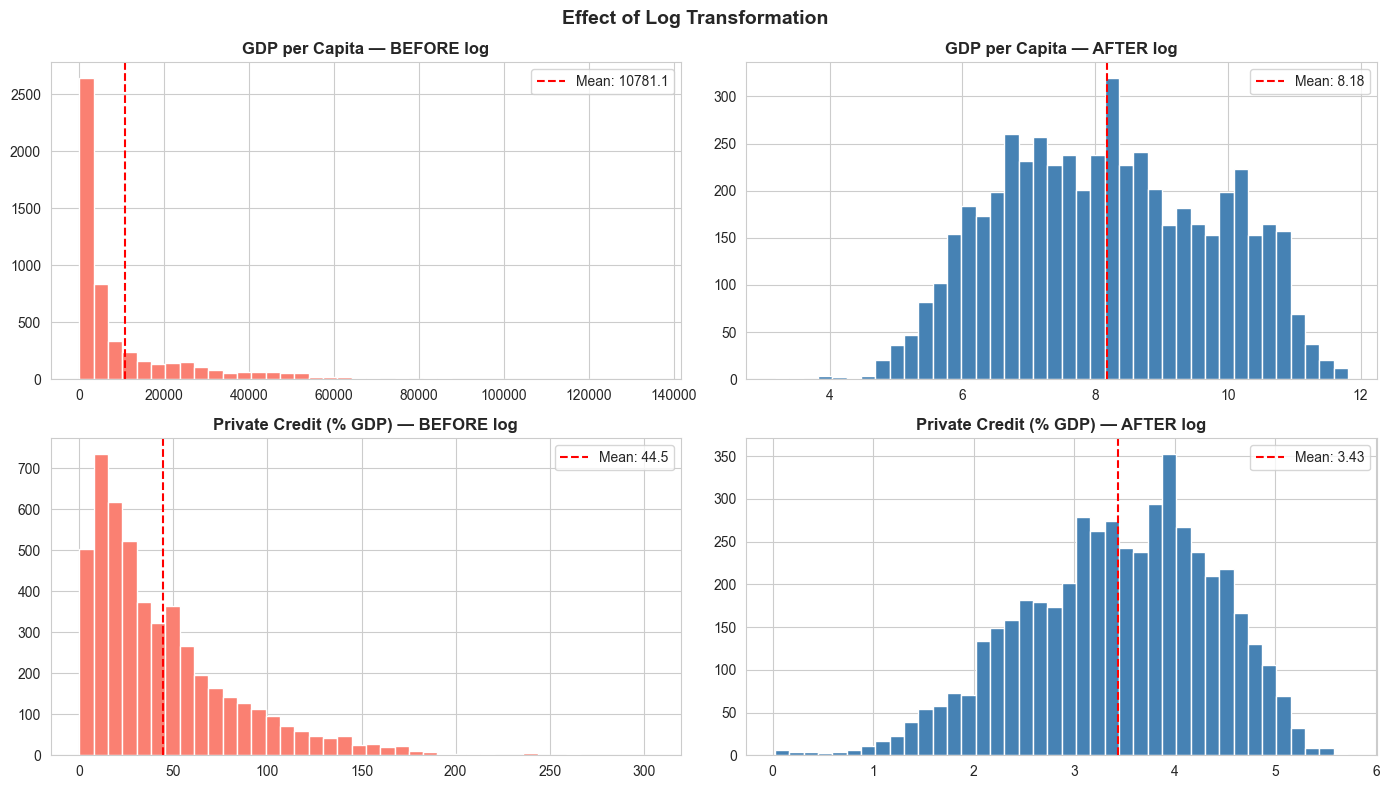

Log transformation applied!
Shape: (5376, 21)
New columns: log_gdp_per_capita, log_private_credit_gdp


In [7]:
# === STEP 4: LOG TRANSFORM SKEWED COLUMNS ===
# From EDA distributions we identified 4 heavily right-skewed columns
# Log transformation compresses large values and spreads small ones
# making the distribution more normal — which ML models prefer

# We use log(1 + x) instead of log(x) to handle zero values safely
# log(0) is undefined, log(1+0) = 0 — no errors

cols_to_log = {
    'gdp_per_capita':   'GDP per Capita',
    'private_credit_gdp': 'Private Credit (% GDP)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (col, title) in enumerate(cols_to_log.items()):
    original = df[col].dropna()
    transformed = np.log1p(df[col].dropna())

    # Before
    axes[i][0].hist(original, bins=40, color='salmon', edgecolor='white')
    axes[i][0].set_title(f'{title} — BEFORE log', fontweight='bold')
    axes[i][0].axvline(original.mean(), color='red', linestyle='--',
                       label=f'Mean: {original.mean():.1f}')
    axes[i][0].legend()

    # After
    axes[i][1].hist(transformed, bins=40, color='steelblue', edgecolor='white')
    axes[i][1].set_title(f'{title} — AFTER log', fontweight='bold')
    axes[i][1].axvline(transformed.mean(), color='red', linestyle='--',
                       label=f'Mean: {transformed.mean():.2f}')
    axes[i][1].legend()

plt.suptitle('Effect of Log Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Apply the transformation
# Store as new columns — keep originals for reference
df['log_gdp_per_capita']    = np.log1p(df['gdp_per_capita'])
df['log_private_credit_gdp'] = np.log1p(df['private_credit_gdp'])

# Drop original skewed columns — we'll use log versions in the model
df = df.drop(columns=['gdp_per_capita', 'private_credit_gdp'])

print('Log transformation applied!')
print(f'Shape: {df.shape}')
print(f'New columns: log_gdp_per_capita, log_private_credit_gdp')

In [8]:
# === STEP 5: IMPUTE MISSING VALUES ===
# Strategy: forward-fill then backward-fill within each country
# 
# Forward-fill: if 2005 is missing, use 2004's value
# Backward-fill: if 1990 is missing, use 1991's value
# 
# This makes sense for time series — a country's GDP in 2005 is
# probably close to its 2004 value. Much better than using the
# global mean which ignores the country's own trend.

print('=== MISSING VALUES BEFORE IMPUTATION ===')
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print(missing_before)

# Sort by country and year first — critical for forward/backward fill to work correctly
df = df.sort_values(['country_code', 'year']).reset_index(drop=True)

# Get numeric columns only (don't try to fill country_name etc.)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

# Apply forward-fill then backward-fill within each country group
df[numeric_cols] = (
    df.groupby('country_code')[numeric_cols]
    .transform(lambda x: x.ffill().bfill())
)

print('\n=== MISSING VALUES AFTER IMPUTATION ===')
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
if len(missing_after) == 0:
    print('No missing values remaining! ✅')
else:
    print(missing_after)

print(f'\nShape: {df.shape}')

=== MISSING VALUES BEFORE IMPUTATION ===
bank_capital_ratio        3011
bank_npl                  2934
edu_expenditure           2749
clean_water_access        2621
bank_roa                  2299
bank_zscore               2243
govt_expenditure          2064
secondary_enrollment      1842
primary_enrollment        1200
internet_users             600
trade_pct_gdp              584
liquid_liabilities_gdp     488
log_private_credit_gdp     428
inflation                  374
unemployment               199
log_gdp_per_capita          26
dtype: int64

=== MISSING VALUES AFTER IMPUTATION ===
clean_water_access        1344
bank_capital_ratio         928
bank_npl                   896
govt_expenditure           672
bank_zscore                352
trade_pct_gdp              288
bank_roa                   256
edu_expenditure            192
secondary_enrollment       128
primary_enrollment          96
liquid_liabilities_gdp      32
unemployment                32
dtype: int64

Shape: (5376, 21)


In [9]:
# === STEP 6: FILL REMAINING NULLS WITH GLOBAL MEDIAN ===
# Some countries never reported certain indicators at all
# ffill/bfill couldn't help because there was nothing to propagate
# For these we use the global median — a neutral, robust fallback
# We use MEDIAN not mean because it's resistant to outliers

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

for col in numeric_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  {col:<30} filled {missing_count} NULLs with median={median_val:.3f}')

print('\n=== FINAL MISSING CHECK ===')
remaining = df.isnull().sum().sum()
print(f'Total missing values remaining: {remaining}')

if remaining == 0:
    print('Dataset is fully clean — no NULLs! ✅')

  unemployment                   filled 32 NULLs with median=6.358
  trade_pct_gdp                  filled 288 NULLs with median=71.808
  govt_expenditure               filled 672 NULLs with median=22.766
  liquid_liabilities_gdp         filled 32 NULLs with median=45.452
  bank_zscore                    filled 352 NULLs with median=14.786
  bank_npl                       filled 896 NULLs with median=5.300
  bank_capital_ratio             filled 928 NULLs with median=9.500
  bank_roa                       filled 256 NULLs with median=1.189
  clean_water_access             filled 1344 NULLs with median=69.360
  primary_enrollment             filled 96 NULLs with median=101.879
  secondary_enrollment           filled 128 NULLs with median=81.180
  edu_expenditure                filled 192 NULLs with median=4.124

=== FINAL MISSING CHECK ===
Total missing values remaining: 0
Dataset is fully clean — no NULLs! ✅


=== HDI PROXY SCORE ===
count    5376.000
mean        0.664
std         0.187
min         0.092
25%         0.523
50%         0.694
75%         0.812
max         0.975
Name: hdi_proxy, dtype: float64


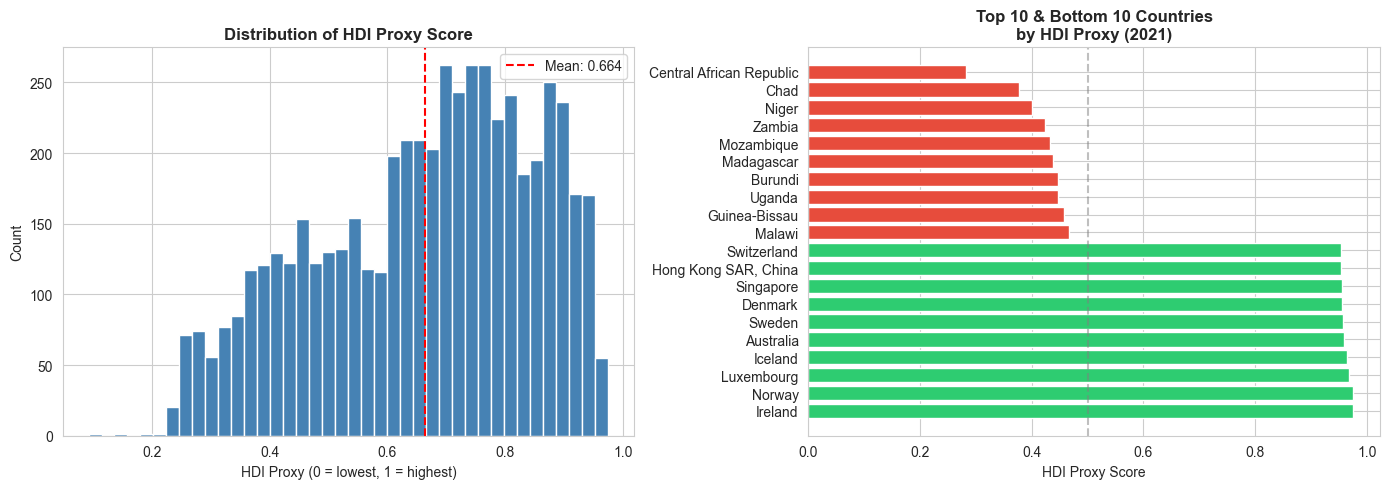


=== SPOT CHECK: HDI Proxy for key countries in 2021 ===
       country_name country_code  hdi_proxy
1279        Germany          DEU   0.902435
5055  United States          USA   0.898847
959           China          CHN   0.806227
671          Brazil          BRA   0.787175
2207          India          IND   0.643731
3583        Nigeria          NGA   0.488225


In [10]:
# === STEP 7: BUILD THE HDI PROXY SCORE ===
# This is our TARGET VARIABLE — what we're trying to forecast
#
# The real UN HDI combines:
#   1. Income dimension    → GDP per capita (log)
#   2. Health dimension    → Life expectancy
#   3. Education dimension → Years of schooling
#
# We mirror this using our available columns:
#   1. Income    → log_gdp_per_capita
#   2. Health    → life_expectancy
#   3. Education → secondary_enrollment
#
# Each dimension is normalized to 0-1 scale first
# Then averaged equally — just like the real HDI formula

def normalize(series):
    """Scale any series to 0-1 range"""
    return (series - series.min()) / (series.max() - series.min())

# Normalize each dimension
df['income_idx']    = normalize(df['log_gdp_per_capita'])
df['health_idx']    = normalize(df['life_expectancy'])
df['education_idx'] = normalize(df['secondary_enrollment'])

# HDI proxy = equal weighted average of three dimensions
df['hdi_proxy'] = (df['income_idx'] + 
                   df['health_idx'] + 
                   df['education_idx']) / 3

print('=== HDI PROXY SCORE ===')
print(df['hdi_proxy'].describe().round(3))

# Visualize distribution of HDI proxy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['hdi_proxy'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of HDI Proxy Score', fontweight='bold')
axes[0].set_xlabel('HDI Proxy (0 = lowest, 1 = highest)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['hdi_proxy'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['hdi_proxy'].mean():.3f}")
axes[0].legend()

# Top and bottom 10 countries (latest year)
latest = df[df['year'] == 2021].sort_values('hdi_proxy', ascending=False)
top10    = latest.head(10)[['country_name', 'hdi_proxy']]
bottom10 = latest.tail(10)[['country_name', 'hdi_proxy']]

combined = pd.concat([top10, bottom10])
colors_bar = ['#2ecc71'] * 10 + ['#e74c3c'] * 10

axes[1].barh(combined['country_name'], combined['hdi_proxy'], 
             color=colors_bar, edgecolor='white')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Top 10 & Bottom 10 Countries\nby HDI Proxy (2021)', 
                  fontweight='bold')
axes[1].set_xlabel('HDI Proxy Score')
plt.tight_layout()
plt.show()

# Spot check — do the scores make sense?
print('\n=== SPOT CHECK: HDI Proxy for key countries in 2021 ===')
check = df[df['year'] == 2021][['country_name', 'hdi_proxy']]\
        .sort_values('hdi_proxy', ascending=False)
key_cc = ['USA', 'DEU', 'CHN', 'BRA', 'IND', 'NGA']
print(df[(df['country_code'].isin(key_cc)) & (df['year'] == 2021)]
      [['country_name', 'country_code', 'hdi_proxy']]
      .sort_values('hdi_proxy', ascending=False))

In [11]:
# === STEP 8: CREATE TARGET VARIABLE ===
# We want to forecast HDI proxy 5 years into the future
# So for each country-year row, the target = that country's HDI proxy 5 years later
#
# Example:
# Brazil 2005 → target = Brazil's HDI proxy in 2010
# Brazil 2006 → target = Brazil's HDI proxy in 2011
# ...
# Brazil 2016 → target = Brazil's HDI proxy in 2021 (last available)
# Brazil 2017 → target = NaN (we don't have 2022 data)

df = df.sort_values(['country_code', 'year']).reset_index(drop=True)

# Shift hdi_proxy by -5 within each country group
df['hdi_proxy_t5'] = (
    df.groupby('country_code')['hdi_proxy']
    .shift(-5)
)

# Check how many rows have a valid target
valid = df['hdi_proxy_t5'].notna().sum()
total = len(df)
print(f'Rows with valid target: {valid} / {total}')
print(f'Rows without target (last 5 years per country): {total - valid}')

# Verify with an example
print('\n=== EXAMPLE: Brazil ===')
brazil = df[df['country_code'] == 'BRA'][['country_name', 'year', 'hdi_proxy', 'hdi_proxy_t5']]
print(brazil.tail(10).to_string())

Rows with valid target: 4536 / 5376
Rows without target (last 5 years per country): 840

=== EXAMPLE: Brazil ===
    country_name  year  hdi_proxy  hdi_proxy_t5
662       Brazil  2012   0.810490      0.806882
663       Brazil  2013   0.811541      0.804910
664       Brazil  2014   0.811939      0.804570
665       Brazil  2015   0.800974      0.789231
666       Brazil  2016   0.800426      0.787175
667       Brazil  2017   0.806882           NaN
668       Brazil  2018   0.804910           NaN
669       Brazil  2019   0.804570           NaN
670       Brazil  2020   0.789231           NaN
671       Brazil  2021   0.787175           NaN


In [12]:
# === STEP 9: SAVE CLEAN DATASET ===

# Split into two files:
# 1. Training data — rows with valid target (used to train models)
# 2. Forecast data — rows without target (used to generate predictions)

df_train    = df[df['hdi_proxy_t5'].notna()].copy()
df_forecast = df[df['hdi_proxy_t5'].isna()].copy()

# Save both
df_train.to_csv('../data/country_panel_clean.csv', index=False)
df_forecast.to_csv('../data/country_panel_forecast.csv', index=False)

# Also save the full clean dataset
df.to_csv('../data/country_panel_full_clean.csv', index=False)

print('=== FILES SAVED ===')
print(f'country_panel_clean.csv    → {df_train.shape} (training data)')
print(f'country_panel_forecast.csv → {df_forecast.shape} (for generating forecasts)')
print(f'country_panel_full_clean.csv → {df.shape} (full dataset)')

print('\n=== FINAL DATASET SUMMARY ===')
print(f'Countries:        {df_train.country_code.nunique()}')
print(f'Years (training): {df_train.year.min()} – {df_train.year.max()}')
print(f'Features:         {df_train.shape[1] - 5} indicators')
print(f'Target:           hdi_proxy_t5 (HDI proxy 5 years ahead)')
print(f'Missing values:   {df_train.isnull().sum().sum()}')

print('\n=== FEATURE LIST ===')
feature_cols = [c for c in df_train.columns 
                if c not in ['country_name', 'country_code', 'year', 
                             'hdi_proxy', 'hdi_proxy_t5',
                             'income_idx', 'health_idx', 'education_idx']]
print(feature_cols)

=== FILES SAVED ===
country_panel_clean.csv    → (4536, 26) (training data)
country_panel_forecast.csv → (840, 26) (for generating forecasts)
country_panel_full_clean.csv → (5376, 26) (full dataset)

=== FINAL DATASET SUMMARY ===
Countries:        168
Years (training): 1990 – 2016
Features:         21 indicators
Target:           hdi_proxy_t5 (HDI proxy 5 years ahead)
Missing values:   0

=== FEATURE LIST ===
['inflation', 'unemployment', 'trade_pct_gdp', 'govt_expenditure', 'urban_pop_pct', 'internet_users', 'liquid_liabilities_gdp', 'bank_zscore', 'bank_npl', 'bank_capital_ratio', 'bank_roa', 'life_expectancy', 'clean_water_access', 'primary_enrollment', 'secondary_enrollment', 'edu_expenditure', 'log_gdp_per_capita', 'log_private_credit_gdp']
